In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# Download the preprocessed data
X_train = pd.read_csv("../clean_data/X_train.csv")
X_test = pd.read_csv("../clean_data/X_test.csv")
y_train = pd.read_csv("../clean_data/y_train.csv")
y_test = pd.read_csv("../clean_data/y_test.csv")

In [3]:
# Encodage de la variaable mois en variables sin et cos pour capturer la cyclicité
X_train["Month_sin"] = np.sin(2 * np.pi * X_train["Month"] / 12)
X_train["Month_cos"] = np.cos(2 * np.pi * X_train["Month"] / 12)

X_test["Month_sin"] = np.sin(2 * np.pi * X_test["Month"] / 12)
X_test["Month_cos"] = np.cos(2 * np.pi * X_test["Month"] / 12)

# Encodage de la variable "Day" en variables sin et cos pour capturer la cyclicité
X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day"] / 31)
X_train["Day_cos"] = np.cos(2 * np.pi * X_train["Day"] / 31)

X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day"] / 31)
X_test["Day_cos"] = np.cos(2 * np.pi * X_test["Day"] / 31)

# Sppression de la variable "Month" et "Day" après l'encodage
X_train = X_train.drop(columns=["Month", "Day"])
X_test = X_test.drop(columns=["Month", "Day"])

In [4]:
# Entraînement
# Ensure y are 1D
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Compute class ratio for scale_pos_weight (avoid div by zero)
fraud = (y_train == 1).sum()
normal = (y_train == 0).sum()
ratio = normal / fraud if fraud != 0 else 1
print(f"scale_pos_weight = {ratio:.2f}")

# Create and train the model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model.fit(X_train, y_train)


scale_pos_weight = 19.64


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

In [6]:
## Évaluation du modèle
print("=" * 50)
print("XGBoost")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")

print("\nMatrice de confusion")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))




XGBoost
Accuracy : 0.8461
Precision : 0.0579
Recall : 0.1423
F1-score : 0.0823
ROC-AUC : 0.5493

Matrice de confusion
[[8392 1123]
 [ 416   69]]

Classification Report
              precision    recall  f1-score   support

      Normal       0.95      0.88      0.92      9515
       Fraud       0.06      0.14      0.08       485

    accuracy                           0.85     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.91      0.85      0.88     10000



PRESENTATION DES RESULTATS


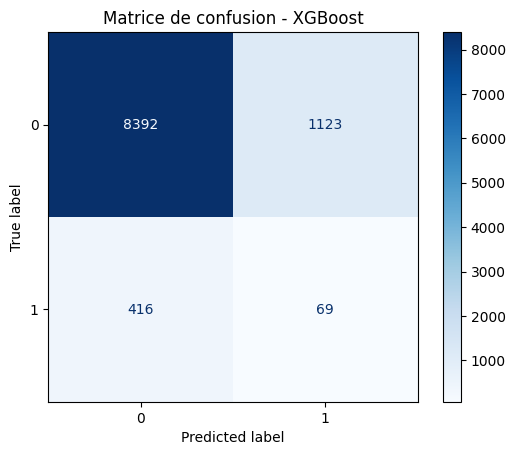

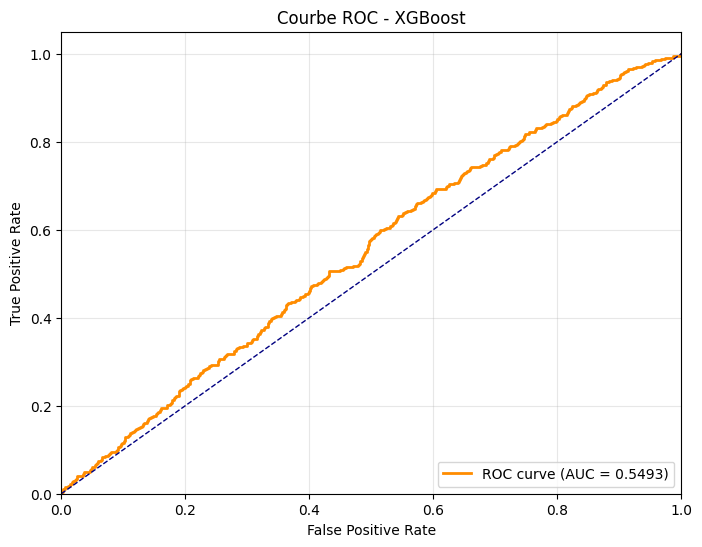

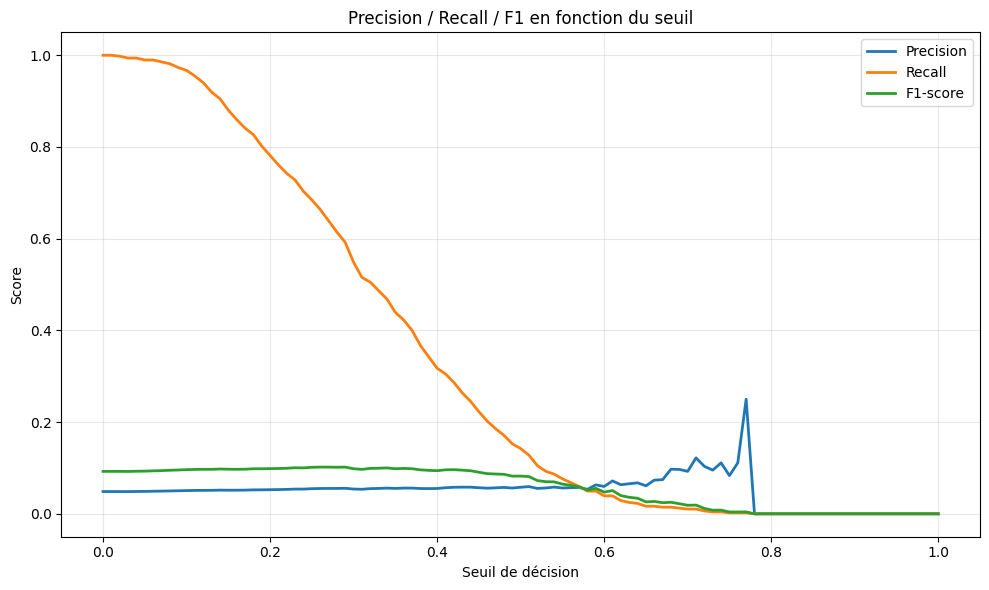

In [7]:
print("=" * 60)
print("PRESENTATION DES RESULTATS")
print("=" * 60)

#Affichage de la matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Matrice de confusion - XGBoost")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - XGBoost")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Precision/Recall/F1 as a function of threshold
thresholds = np.linspace(0.0, 1.0, 101)
precision_vals = []
recall_vals = []
f1_vals = []

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    precision_vals.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recall_vals.append(recall_score(y_test, y_pred_thr, zero_division=0))
    f1_vals.append(f1_score(y_test, y_pred_thr, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_vals, label="Precision", linewidth=2)
plt.plot(thresholds, recall_vals, label="Recall", linewidth=2)
plt.plot(thresholds, f1_vals, label="F1-score", linewidth=2)
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 en fonction du seuil")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
